# Rendre le chiffre défendable, puis trouver le gain suivant

**Hier.** L'ajustement de TrOCR a fait passer la lecture de 6 % à 65 %, sur une séparation
unique avec 42 bulletins de test.

**Aujourd'hui, deux choses, dans cet ordre.**

| Partie | Ce qu'elle règle |
|---|---|
| **A** | le chiffre d'hier n'est pas défendable — validation croisée |
| **B** | le gain suivant n'a pas été cherché — complémentarité |

---



---

## Ce que le notebook produit

- un taux avec intervalle de confiance et dispersion entre blocs ;
- le verdict explicite : peut-on ou non annoncer une différence avec gemma4 ;
- le tableau croisé TrOCR contre gemma4-bloc, et l'**oracle**  ce qu'une combinaison
  parfaite atteindrait ;
- tout tracé dans MLflow, avec la graine et la liste des bulletins de test.

In [ ]:
%pip install -q sentencepiece protobuf "accelerate>=1.1.0" scipy

**Redémarre le noyau**, puis reprends ci-dessous.

In [1]:
import io
import json
import os
import platform
import random
import re
import shutil
import subprocess
import time
import unicodedata
from pathlib import Path

os.environ["HF_HOME"] = os.path.expanduser("~/work/.cache/huggingface")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageEnhance
from scipy import stats

# --- Tous les reglages ici -------------------------------------------
GRAINE = 42
K_BLOCS = 5

BUCKET = "projet-mesure-qualite-rp"
CAMPAGNE = "RG25"
CHAMPS = ["NOM", "PRENOM"]
POS_UT, POS_CAB = 2, 4
COLS = {"NOM": 11, "PRENOM": 12}
FICHIER_FIQUAL = "RP_PMQ_FIQUAL2599.txt"

MODELE_DEPART = "microsoft/trocr-base-handwritten"
EPOQUES = 12
LEARNING_RATE = 5e-6
BATCH_SIZE = 4
MAX_LONGUEUR = 32

ZONES_SECOURS = {"NOM": (0.155, 0.083, 0.245, 0.011),
                 "PRENOM": (0.155, 0.094, 0.245, 0.011)}
# Le bloc identite : zone large avec les libelles imprimes
BORDS_BLOC = (0.075, 0.072, 0.450, 0.105)

MODELE_SERVICE = "gemma4-26b-moe"
REPERE_LIGNE = {"NOM": 0.586, "PRENOM": 0.680}

random.seed(GRAINE)
np.random.seed(GRAINE)
torch.manual_seed(GRAINE)

APPAREIL = "cuda" if torch.cuda.is_available() else "cpu"
print("appareil :", APPAREIL)
if APPAREIL == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"carte    : {torch.cuda.get_device_name(0)} — {p.total_memory/1e9:.0f} Go")
print(f"disque   : {shutil.disk_usage(os.path.expanduser('~/work')).free/1e9:.1f} Go")

mkdir -p failed for path /home/onyxia/.config/matplotlib: [Errno 13] Permission denied: '/home/onyxia/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-4j7h9a1w because there was an issue with the default path (/home/onyxia/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


appareil : cuda
carte    : Tesla T4 — 16 Go
disque   : 0.6 Go


In [13]:
os.environ["HF_HOME"] = "/tmp/hf-cache"
os.environ["UV_CACHE_DIR"] = "/tmp/uv-cache"
os.environ["UV_PROJECT_ENVIRONMENT"] = "/tmp/mqrp-venv"

In [2]:
def normaliser(t):
    if t is None or (isinstance(t, float) and pd.isna(t)):
        return ""
    t = unicodedata.normalize("NFKD", str(t).strip())
    t = "".join(c for c in t if not unicodedata.combining(c)).upper()
    t = re.sub(r"[^A-Z0-9 ]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


def distance(a, b):
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prec = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cour = [i]
        for j, cb in enumerate(b, 1):
            cour.append(min(prec[j] + 1, cour[j - 1] + 1, prec[j - 1] + (ca != cb)))
        prec = cour
    return prec[-1]


def wilson(k, n, z=1.96):
    """Intervalle de confiance valide sur petits effectifs."""
    if n == 0:
        return 0.0, 1.0
    p = k / n
    d = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / d
    demi = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return max(0.0, centre - demi), min(1.0, centre + demi)


def mcnemar(a_ok, b_ok, nom_a="A", nom_b="B"):
    """Test apparie : ne regarde que les lignes ou les deux different."""
    a, b = np.asarray(a_ok, int), np.asarray(b_ok, int)
    n10 = int(((a == 1) & (b == 0)).sum())
    n01 = int(((a == 0) & (b == 1)).sum())
    p = 1.0 if n10 + n01 == 0 else float(
        stats.binomtest(n10, n10 + n01, 0.5).pvalue)
    return {"n11": int(((a == 1) & (b == 1)).sum()),
            f"{nom_a}_seul": n10, f"{nom_b}_seul": n01,
            "n00": int(((a == 0) & (b == 0)).sum()),
            "p": p, "significatif": p < 0.05}



outils prets


---

# 1. Les données

Pour chaque bulletin on prépare **trois** vignettes : la ligne du nom, la ligne du prénom,
et le **bloc entier** avec ses libellés imprimés.

Les deux premières servent à TrOCR, la troisième à gemma4. C'est ce qui permettra de les
comparer sur les mêmes bulletins.

In [3]:
import s3fs
fs = s3fs.S3FileSystem()


def charger(chemin):
    with fs.open(chemin, "rb") as f:
        return Image.open(io.BytesIO(f.read())).convert("RGB")


def decouper_frac(image, zone):
    L, H = image.size
    x, y, w, h = zone
    return image.crop((int(x * L), int(y * H), int((x + w) * L), int((y + h) * H)))


cz = Path(f"configs/positions_BI_{CAMPAGNE}.json")
if cz.exists():
    ZONES = {k: tuple(v) for k, v in
             json.loads(cz.read_text(encoding="utf-8"))["zones"].items()}
    source_zones = str(cz)
else:
    ZONES = dict(ZONES_SECOURS)
    source_zones = "secours"

g, h, d_, b_ = BORDS_BLOC
ZONE_BLOC = (g, h, round(d_ - g, 4), round(b_ - h, 4))
print("zones lignes :", source_zones)
print("zone bloc    :", ZONE_BLOC)

fichiers = [f for f in fs.find(f"{BUCKET}/data/raw/{CAMPAGNE}/BIE")
            if f.endswith("_BI.jpg")]
bi = pd.DataFrame({"chemin": fichiers})
m = bi.chemin.map(lambda c: Path(c).stem).str.split("_")
bi["cle"] = m.str[0] + "_" + m.str[1]

brut = pd.read_csv(f"s3://{BUCKET}/data/raw/{CAMPAGNE}/{FICHIER_FIQUAL}",
                   sep="\x00", header=None, names=["ligne"], dtype=str,
                   encoding="latin-1", keep_default_na=False,
                   engine="python")["ligne"]
ch = brut.str.split("|")
fq3 = pd.DataFrame(ch[ch.str[0] == "3"].tolist(), dtype=str)
fq3["cle"] = fq3[POS_UT].str.strip() + "_" + fq3[POS_CAB].str.strip()
ref = fq3[["cle", COLS["NOM"], COLS["PRENOM"]]].copy()
ref.columns = ["cle", "ref_NOM", "ref_PRENOM"]
for c in ["ref_NOM", "ref_PRENOM"]:
    ref[c] = ref[c].str.strip()

app = bi.merge(ref, on="cle", how="inner").reset_index(drop=True)
print(f"\n{len(app)} bulletins apparies sur {len(bi)} images")

LIGNES, BLOCS = [], []
for _, r in app.iterrows():
    page = charger(r.chemin)
    for champ in CHAMPS:
        texte = str(r.get(f"ref_{champ}", "")).strip()
        if texte and champ in ZONES:
            LIGNES.append({"id": f"{r.cle}__{champ}", "cle": r.cle, "champ": champ,
                           "texte": texte,
                           "image": decouper_frac(page, ZONES[champ])})
    BLOCS.append({"cle": r.cle, "image": decouper_frac(page, ZONE_BLOC),
                  "NOM": str(r.get("ref_NOM", "")).strip(),
                  "PRENOM": str(r.get("ref_PRENOM", "")).strip()})

print(f"{len(LIGNES)} lignes, {len(BLOCS)} blocs")

zones lignes : secours
zone bloc    : (0.075, 0.072, 0.375, 0.033)

169 bulletins apparies sur 305 images
335 lignes, 169 blocs


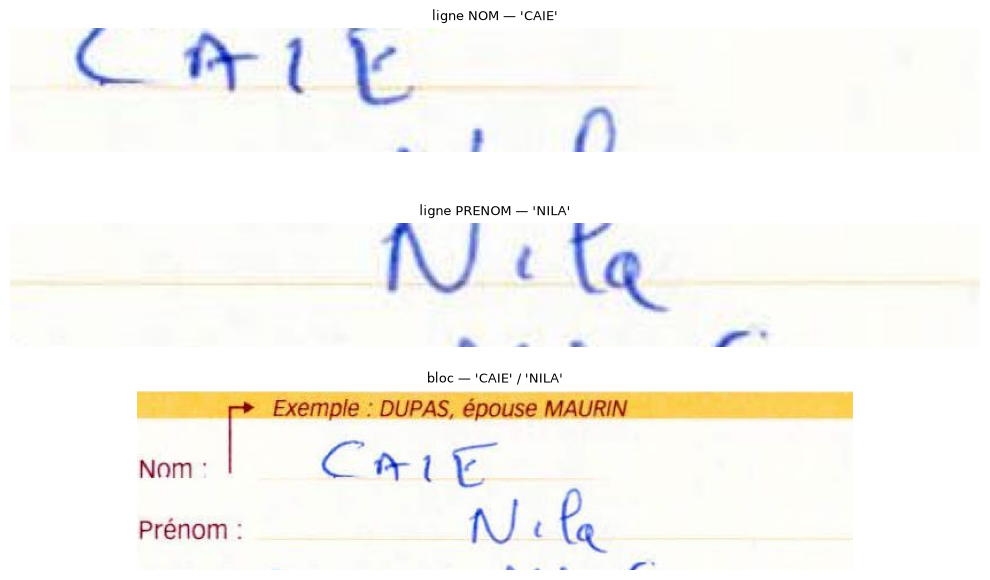

Le bloc doit contenir les libelles 'Nom :' et 'Prenom :' ENTIERS,
et les deux lignes manuscrites completes. C'est ce contexte qui
explique les 24 points d'ecart avec la ligne isolee.


In [4]:
# Controle visuel : une vignette tronquee fausse tout sans lever d'erreur
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for ax, v, t in [(axes[0], LIGNES[0]["image"],
                  f"ligne NOM — {LIGNES[0]['texte']!r}"),
                 (axes[1], LIGNES[1]["image"],
                  f"ligne PRENOM — {LIGNES[1]['texte']!r}"),
                 (axes[2], BLOCS[0]["image"],
                  f"bloc — {BLOCS[0]['NOM']!r} / {BLOCS[0]['PRENOM']!r}")]:
    ax.imshow(v)
    ax.set_title(t, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Le bloc doit contenir les libelles 'Nom :' et 'Prenom :' ENTIERS,")
print("et les deux lignes manuscrites completes. C'est ce contexte qui")
print("explique les 24 points d'ecart avec la ligne isolee.")

---

# PARTIE A Validation croisée

Cinq blocs découpés **par bulletin** : le nom et le prénom d'une même personne restent du
même côté, sinon le modèle aurait déjà vu cette écriture et le test serait faussé.

In [5]:
def blocs_par_bulletin(lignes, k=K_BLOCS, graine=GRAINE):
    r = np.random.default_rng(graine)
    cles = sorted({l["cle"] for l in lignes})
    r.shuffle(cles)
    parts = np.array_split(np.array(cles), k)
    sorties = []
    for p in parts:
        test = set(p)
        sorties.append((test,
                        [l for l in lignes if l["cle"] not in test],
                        [l for l in lignes if l["cle"] in test]))
    return sorties


DECOUPES = blocs_par_bulletin(LIGNES)
for i, (ct, tr, te) in enumerate(DECOUPES, 1):
    fuite = bool({l["cle"] for l in tr} & {l["cle"] for l in te})
    print(f"bloc {i} : {len(ct):3} bulletins test, train {len(tr):3}, "
          f"test {len(te):3}, fuite {fuite}")

testees = [l["id"] for _, _, te in DECOUPES for l in te]
print(f"\nchaque ligne testee une seule fois : {len(set(testees)) == len(LIGNES)}")

bloc 1 :  34 bulletins test, train 268, test  67, fuite False
bloc 2 :  34 bulletins test, train 267, test  68, fuite False
bloc 3 :  34 bulletins test, train 267, test  68, fuite False
bloc 4 :  34 bulletins test, train 269, test  66, fuite False
bloc 5 :  33 bulletins test, train 269, test  66, fuite False

chaque ligne testee une seule fois : True


In [6]:
from huggingface_hub import snapshot_download
from transformers import VisionEncoderDecoderModel

DOSSIER = snapshot_download(MODELE_DEPART)
img_proc = tokenizer = None
strategie = None


def _tenter(nom, f):
    global img_proc, tokenizer, strategie
    if strategie:
        return
    try:
        ip, tk = f()
        img_proc, tokenizer, strategie = ip, tk, nom
        print(f"  {nom:28} OK")
    except Exception as e:
        print(f"  {nom:28} {type(e).__name__}")


def _t1():
    from transformers import TrOCRProcessor
    p = TrOCRProcessor.from_pretrained(MODELE_DEPART)
    return p.image_processor, p.tokenizer


def _t2():
    from transformers import TrOCRProcessor
    p = TrOCRProcessor.from_pretrained(MODELE_DEPART, use_fast=False)
    return p.image_processor, p.tokenizer


def _t3():
    from transformers import ViTImageProcessor, RobertaTokenizer
    return (ViTImageProcessor.from_pretrained(MODELE_DEPART),
            RobertaTokenizer.from_pretrained(MODELE_DEPART))


def _t4():
    from transformers import ViTImageProcessor, RobertaTokenizer
    dd = Path(DOSSIER)
    return (ViTImageProcessor.from_pretrained(str(dd)),
            RobertaTokenizer(vocab_file=str(dd / "vocab.json"),
                             merges_file=str(dd / "merges.txt")))


print("chargement de TrOCR :")
for nom, f in [("1 standard", _t1), ("2 tokenizer lent", _t2),
               ("3 classes explicites", _t3), ("4 fichiers locaux", _t4)]:
    _tenter(nom, f)

_t = VisionEncoderDecoderModel.from_pretrained(MODELE_DEPART)
N_PARAM = sum(p.numel() for p in _t.parameters())
del _t
print(f"\n{N_PARAM/1e6:.0f} M parametres")

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 803.67it/s]


chargement de TrOCR :
  1 standard                   OK


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 2709.81it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



334 M parametres


In [7]:
from torch.utils.data import Dataset
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments


def augmentation(image):
    im = image
    if random.random() < 0.7:
        im = im.rotate(random.uniform(-1.5, 1.5), resample=Image.BILINEAR,
                       fillcolor=(255, 255, 255))
    if random.random() < 0.5:
        im = ImageEnhance.Contrast(im).enhance(random.uniform(0.8, 1.3))
    if random.random() < 0.5:
        im = ImageEnhance.Brightness(im).enhance(random.uniform(0.85, 1.15))
    return im


class JeuLignes(Dataset):
    def __init__(self, lignes, augmenter=False):
        self.lignes, self.augmenter = lignes, augmenter

    def __len__(self):
        return len(self.lignes)

    def __getitem__(self, i):
        item = self.lignes[i]
        image = augmentation(item["image"]) if self.augmenter else item["image"]
        px = img_proc(images=image, return_tensors="pt").pixel_values[0]
        ids = tokenizer(item["texte"], padding="max_length", truncation=True,
                        max_length=MAX_LONGUEUR).input_ids
        ids = [t if t != tokenizer.pad_token_id else -100 for t in ids]
        return {"pixel_values": px, "labels": torch.tensor(ids)}


def nouveau_modele():
    m = VisionEncoderDecoderModel.from_pretrained(MODELE_DEPART).to(APPAREIL)
    m.config.decoder_start_token_id = tokenizer.cls_token_id
    m.config.pad_token_id = tokenizer.pad_token_id
    m.config.eos_token_id = tokenizer.sep_token_id
    m.config.vocab_size = m.config.decoder.vocab_size
    m.generation_config.max_new_tokens = MAX_LONGUEUR
    m.generation_config.num_beams = 1
    return m


@torch.no_grad()
def lire(modele, lignes, lot=8):
    modele.eval()
    im = [l["image"] for l in lignes]
    out = []
    for i in range(0, len(im), lot):
        px = img_proc(images=im[i:i + lot],
                      return_tensors="pt").pixel_values.to(APPAREIL)
        ids = modele.generate(px, max_new_tokens=MAX_LONGUEUR, num_beams=1)
        out.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return [s.strip() for s in out]


def tableau(lignes, lus, etat, bloc):
    d = pd.DataFrame({"id": [l["id"] for l in lignes],
                      "cle": [l["cle"] for l in lignes],
                      "champ": [l["champ"] for l in lignes],
                      "attendu": [l["texte"] for l in lignes],
                      "lu": lus, "etat": etat, "bloc": bloc})
    d["attendu_n"] = d.attendu.map(normaliser)
    d["lu_n"] = d.lu.map(normaliser)
    d["exact"] = (d.lu_n == d.attendu_n).astype(int)
    d["dist"] = [distance(a, b) for a, b in zip(d.lu_n, d.attendu_n)]
    d["len"] = d.attendu_n.str.len()
    return d

In [16]:
import gc
import mlflow
mlflow.set_experiment("fiqual-banc-essai")

tous = []
t_global = time.time()

for i, (cles_test, TRAIN, TEST) in enumerate(DECOUPES, 1):
    print(f"\n{'='*58}\nBLOC {i}/{K_BLOCS} - train {len(TRAIN)}, test {len(TEST)}")

    if APPAREIL == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    modele = nouveau_modele()
    d_av = tableau(TEST, lire(modele, TEST), "avant", i)
    print(f"  avant : {d_av.exact.mean():.1%}")

    args = Seq2SeqTrainingArguments(
        output_dir=f"/tmp/trocr_b{i}",      # hors de ~/work
        save_strategy="no",                  # aucun checkpoint : le modele est evalue en memoire
        per_device_train_batch_size=BATCH_SIZE,
        num_train_epochs=EPOQUES, learning_rate=LEARNING_RATE,
        logging_steps=20, report_to=[], remove_unused_columns=False,
        fp16=(APPAREIL == "cuda"), seed=GRAINE)
    tr = Seq2SeqTrainer(model=modele, args=args,
                        train_dataset=JeuLignes(TRAIN, augmenter=True))
    t0 = time.time()
    tr.train()
    duree = time.time() - t0

    d_ap = tableau(TEST, lire(modele, TEST), "apres", i)
    print(f"  apres : {d_ap.exact.mean():.1%}  ({duree/60:.1f} min)")
    tous.append(pd.concat([d_av, d_ap], ignore_index=True))

    # sauvegarde au fil de l'eau : un plantage au bloc suivant ne fait rien perdre
    pd.concat(tous, ignore_index=True).to_csv("cv_trocr.csv", index=False)

    ress = {"appareil": APPAREIL, "python": platform.python_version()}
    if APPAREIL == "cuda":
        p = torch.cuda.get_device_properties(0)
        ress.update({"gpu": torch.cuda.get_device_name(0),
                     "gpu_memoire_pic_Go": round(torch.cuda.max_memory_allocated() / 1e9, 2),
                     "gpu_taux": round(torch.cuda.max_memory_allocated() / p.total_memory, 2)})

    with mlflow.start_run(run_name=f"trocr-cv{K_BLOCS}-bloc{i}"):
        mlflow.log_params({
            "modele_depart": MODELE_DEPART, "n_parametres_M": round(N_PARAM / 1e6),
            "strategie_chargement": strategie, "graine": GRAINE,
            "bloc": i, "k_blocs": K_BLOCS,
            "lignes_entrainement": len(TRAIN), "lignes_test": len(TEST),
            "bulletins_test": len(cles_test),
            "epoques": EPOQUES, "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE, "augmentation": True,
            "campagne": CAMPAGNE, "source_zones": source_zones,
            "entree": "ligne isolee", "duree_minutes": round(duree / 60, 2),
            **ress})
        for h in tr.state.log_history:
            if "loss" in h:
                mlflow.log_metric("perte", float(h["loss"]), step=int(h["step"]))
        mes = {}
        for et, dd in [("avant", d_av), ("apres", d_ap)]:
            mes[f"{et}_exact"] = float(dd.exact.mean())
            mes[f"{et}_cer"] = float(dd.dist.sum() / max(dd["len"].sum(), 1))
            for c, gg in dd.groupby("champ"):
                mes[f"{et}_{c}_exact"] = float(gg.exact.mean())
        mlflow.log_metrics(mes)
        Path(f"bulletins_test_b{i}.txt").write_text("\n".join(sorted(cles_test)))
        mlflow.log_artifact(f"bulletins_test_b{i}.txt")

    # liberation complete de la memoire avant le bloc suivant
    del modele, tr
    gc.collect()
    if APPAREIL == "cuda":
        torch.cuda.empty_cache()

CV = pd.concat(tous, ignore_index=True)
CV.to_csv("cv_trocr.csv", index=False)
print(f"\n{K_BLOCS} blocs en {(time.time()-t_global)/60:.1f} minutes")


BLOC 1/5 - train 268, test 67


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 3760.69it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  avant : 6.0%


Step,Training Loss
20,7.621412
40,2.512771
60,1.338937
80,0.826523
100,0.599265
120,0.554508
140,0.458791
160,0.337716
180,0.149030
200,0.221091


  apres : 71.6%  (3.9 min)
🏃 View run trocr-cv5-bloc1 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/c090aa6051b548aabdb5591b13cb04c0
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1

BLOC 2/5 - train 267, test 68


...

  apres : 63.6%  (3.9 min)
🏃 View run trocr-cv5-bloc4 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/31b193143280443582f78208d84328f2
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1

BLOC 5/5 - train 269, test 66


Loading weights: 100%|██████████| 478/478 [00:00<00:00, 3232.86it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  avant : 3.0%


Step,Training Loss
20,7.199731
40,1.963469
60,1.190109
80,0.796165
100,0.580569
120,0.679867
140,0.422447
160,0.258787
180,0.287124
200,0.180462


  apres : 63.6%  (3.9 min)
🏃 View run trocr-cv5-bloc5 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/05d80af604ba487c9299b42c39707392
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1

5 blocs en 22.2 minutes


In [12]:
!echo 'export UV_CACHE_DIR=/tmp/uv-cache UV_PROJECT_ENVIRONMENT=/tmp/mqrp-venv HF_HOME=/tmp/hf-cache' >> ~/.bashrc

In [17]:
apres = CV[CV.etat == "apres"]
avant = CV[CV.etat == "avant"]

lignes_tab = []
for champ in CHAMPS + ["TOUS"]:
    gp = apres if champ == "TOUS" else apres[apres.champ == champ]
    ga = avant if champ == "TOUS" else avant[avant.champ == champ]
    if not len(gp):
        continue
    k, n = int(gp.exact.sum()), len(gp)
    lo, hi = wilson(k, n)
    lignes_tab.append({
        "champ": champ, "N": n,
        "avant_%": round(ga.exact.mean() * 100, 1),
        "apres_%": round(k / n * 100, 1),
        "IC95": f"[{lo*100:.1f} ; {hi*100:.1f}]",
        "largeur": round((hi - lo) * 100, 1),
        "ecart_blocs": round(gp.groupby("bloc").exact.mean().std(ddof=1) * 100, 1),
        "CER_%": round(gp.dist.sum() / max(gp["len"].sum(), 1) * 100, 1),
    })
resume = pd.DataFrame(lignes_tab)
resume.to_csv("resume_cv.csv", index=False)
display(resume)

,champ,N,avant_%,apres_%,IC95,largeur,ecart_blocs,CER_%
0,NOM,168,7.7,62.5,[55.0 ; 69.5],14.5,11.2,11.1
1,PRENOM,167,8.4,66.5,[59.0 ; 73.2],14.2,8.1,12.5
2,TOUS,335,8.1,64.5,[59.2 ; 69.4],10.2,4.2,11.8


In [18]:
# Le verdict : peut-on annoncer une difference avec gemma4 sur ligne ?
print("Comparaison au repere gemma4 sur ligne isolee :\n")
for champ in CHAMPS:
    g = apres[apres.champ == champ]
    if not len(g) or champ not in REPERE_LIGNE:
        continue
    k, n = int(g.exact.sum()), len(g)
    lo, hi = wilson(k, n)
    rep = REPERE_LIGNE[champ]
    print(f"{champ:8} TrOCR ajuste {k/n:6.1%}  IC95 [{lo:.1%}, {hi:.1%}]")
    print(f"         gemma4 ligne {rep:6.1%}")
    if lo <= rep <= hi:
        print("         -> le repere est DANS l'intervalle")
        print("            NE PAS annoncer de superiorite\n")
    else:
        print("         -> le repere est HORS de l'intervalle")
        print("            ecart plausible, a confirmer par un test apparie\n")

Comparaison au repere gemma4 sur ligne isolee :

NOM      TrOCR ajuste  62.5%  IC95 [55.0%, 69.5%]
         gemma4 ligne  58.6%
         -> le repere est DANS l'intervalle
            NE PAS annoncer de superiorite

PRENOM   TrOCR ajuste  66.5%  IC95 [59.0%, 73.2%]
         gemma4 ligne  68.0%
         -> le repere est DANS l'intervalle
            NE PAS annoncer de superiorite



---

# PARTIE B  La complémentarité avec gemma4 sur bloc

C'est la partie qui cherche le gain suivant.

On interroge gemma4 sur le **bloc entier**, puis on croise ses réussites avec celles de
TrOCR ajusté, **sur les mêmes bulletins**.

In [19]:
import base64
import requests

BASE_URL = "https://llm.lab.sspcloud.fr/api"

if "OPENAI_API_KEY" not in os.environ and shutil.which("vault"):
    r = subprocess.run(["vault", "kv", "get", "-field=OPENAI_API_KEY",
                        "onyxia-kv/farisazibert/LLM"],
                       capture_output=True, text=True)
    if r.returncode == 0 and r.stdout.strip():
        os.environ["OPENAI_API_KEY"] = r.stdout.strip()

cle_ok = "OPENAI_API_KEY" in os.environ
print("cle du service :", cle_ok)
if not cle_ok:
    print('Renseigner : os.environ["OPENAI_API_KEY"] = "..."')

HEADERS = {"Authorization": f"Bearer {os.environ.get('OPENAI_API_KEY','')}"}

PROMPT_BLOC = """Cette image montre un extrait de bulletin individuel du recensement francais.
Elle contient des lignes manuscrites precedees de leurs libelles imprimes :
"Nom :" et "Prenom :".

Transcris ce qui est ecrit a la main sur chacune, en MAJUSCULES, sans accent.

Regles :
- Ne corrige rien, n'ajoute rien, ne devine pas.
- Ne recopie pas les libelles imprimes, seulement l'ecriture manuscrite.
- Si une ligne n'est pas lisible avec certitude, mets exactement ILLISIBLE.

Reponds uniquement en JSON : {"NOM": "...", "PRENOM": "..."}"""


def _b64(image):
    t = io.BytesIO()
    image.convert("RGB").save(t, format="PNG")
    return base64.b64encode(t.getvalue()).decode()


def extraire_json(texte):
    m = re.search(r"\{.*\}", texte, re.S)
    if not m:
        return {}
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return {}


def lire_bloc(image, modele=MODELE_SERVICE, tentatives=3):
    for essai in range(tentatives):
        try:
            r = requests.post(
                f"{BASE_URL}/chat/completions", headers=HEADERS, timeout=180,
                json={"model": modele, "temperature": 0, "max_tokens": 200,
                      "messages": [{"role": "user", "content": [
                          {"type": "image_url", "image_url": {
                              "url": f"data:image/png;base64,{_b64(image)}"}},
                          {"type": "text", "text": PROMPT_BLOC}]}]})
            r.raise_for_status()
            return extraire_json(r.json()["choices"][0]["message"]["content"])
        except Exception:
            time.sleep(2 * (essai + 1))
    return {}


CHEMIN_BLOC = "predictions_gemma4-bloc.csv"

if Path(CHEMIN_BLOC).exists():
    pred_bloc = pd.read_csv(CHEMIN_BLOC, dtype=str).fillna("")
    print(f"{len(pred_bloc)} predictions rechargees depuis {CHEMIN_BLOC}")
elif cle_ok:
    rows = []
    t0 = time.time()
    for i, b in enumerate(BLOCS):
        rep = lire_bloc(b["image"])
        for champ in CHAMPS:
            if b[champ]:
                rows.append({"id": f"{b['cle']}__{champ}", "cle": b["cle"],
                             "champ": champ, "attendu": b[champ],
                             "lu": str(rep.get(champ, ""))})
        if (i + 1) % 25 == 0:
            print(f"  {i+1}/{len(BLOCS)} — {time.time()-t0:.0f} s")
    pred_bloc = pd.DataFrame(rows)
    pred_bloc.to_csv(CHEMIN_BLOC, index=False)
    print(f"\n{len(pred_bloc)} predictions, {(time.time()-t0)/len(BLOCS):.2f} s/bulletin")
else:
    pred_bloc = None
    print("sans cle, la partie B ne peut pas tourner")

cle du service : True
  25/169 — 19 s
  50/169 — 38 s
  75/169 — 56 s
  100/169 — 73 s
  125/169 — 89 s
  150/169 — 104 s

335 predictions, 0.70 s/bulletin


In [20]:
if pred_bloc is not None and len(pred_bloc):
    pb = pred_bloc.copy()
    pb["attendu_n"] = pb.attendu.map(normaliser)
    pb["lu_n"] = pb.lu.map(normaliser)
    pb["exact"] = (pb.lu_n == pb.attendu_n).astype(int)

    print("gemma4 sur bloc entier :")
    for champ, g in pb.groupby("champ"):
        k, n = int(g.exact.sum()), len(g)
        lo, hi = wilson(k, n)
        print(f"  {champ:8} {k/n:6.1%}  IC95 [{lo:.1%}, {hi:.1%}]  (n={n})")
    k, n = int(pb.exact.sum()), len(pb)
    print(f"  {'TOUS':8} {k/n:6.1%}")

gemma4 sur bloc entier :
  NOM       82.1%  IC95 [75.7%, 87.2%]  (n=168)
  PRENOM    86.2%  IC95 [80.2%, 90.6%]  (n=167)
  TOUS      84.2%


In [21]:
# Le croisement : TrOCR ajuste contre gemma4 sur bloc, memes bulletins
def croiser(a_ok, b_ok, nom_a, nom_b):
    a, b = np.asarray(a_ok, int), np.asarray(b_ok, int)
    n = len(a)
    n11 = int(((a == 1) & (b == 1)).sum())
    n10 = int(((a == 1) & (b == 0)).sum())
    n01 = int(((a == 0) & (b == 1)).sum())
    n00 = int(((a == 0) & (b == 0)).sum())
    oracle = (n11 + n10 + n01) / n
    pa, pb_ = 1 - a.mean(), 1 - b.mean()
    surcroit = (n00 / n) / (pa * pb_) if pa * pb_ > 0 else float("nan")
    return {"N": n, nom_a: round(a.mean(), 3), nom_b: round(b.mean(), 3),
            "les_deux": n11, f"{nom_a}_seul": n10, f"{nom_b}_seul": n01,
            "aucun": n00, "oracle": round(oracle, 3),
            "marge": round(oracle - max(a.mean(), b.mean()), 3),
            "co_echec": round(surcroit, 2)}


if pred_bloc is not None and len(pred_bloc):
    comp = apres[["id", "champ", "exact"]].rename(columns={"exact": "trocr_ok"})
    comp = comp.merge(pb[["id", "exact"]].rename(columns={"exact": "bloc_ok"}),
                      on="id", how="inner")
    print(f"{len(comp)} lignes communes\n")

    croises = []
    for champ in CHAMPS + ["TOUS"]:
        g = comp if champ == "TOUS" else comp[comp.champ == champ]
        if not len(g):
            continue
        c = croiser(g.bloc_ok, g.trocr_ok, "bloc", "trocr")
        c["champ"] = champ
        croises.append(c)
        mc = mcnemar(g.bloc_ok, g.trocr_ok, "bloc", "trocr")
        print(f"{champ:8} bloc {c['bloc']:.1%}  trocr {c['trocr']:.1%}  "
              f"oracle {c['oracle']:.1%}  marge {c['marge']:+.1%}  "
              f"co-echec {c['co_echec']}  McNemar p={mc['p']:.4f}")

    croisement = pd.DataFrame(croises)
    croisement.to_csv("complementarite.csv", index=False)
    display(croisement)

335 lignes communes

NOM      bloc 82.1%  trocr 62.5%  oracle 87.5%  marge +5.4%  co-echec 1.87  McNemar p=0.0000
PRENOM   bloc 86.2%  trocr 66.5%  oracle 91.6%  marge +5.4%  co-echec 1.82  McNemar p=0.0000
TOUS     bloc 84.2%  trocr 64.5%  oracle 89.6%  marge +5.4%  co-echec 1.86  McNemar p=0.0000


,N,bloc,trocr,les_deux,bloc_seul,trocr_seul,aucun,oracle,marge,co_echec,champ
0,168,0.821,0.625,96,42,9,21,0.875,0.054,1.87,NOM
1,167,0.862,0.665,102,42,9,14,0.916,0.054,1.82,PRENOM
2,335,0.842,0.645,198,84,18,35,0.896,0.054,1.86,TOUS


In [22]:
# Quelles sont les lignes que TrOCR rattrape ?
if pred_bloc is not None and len(comp):
    rattrape = comp[(comp.bloc_ok == 0) & (comp.trocr_ok == 1)]
    print(f"{len(rattrape)} lignes rattrapees par TrOCR\n")
    if len(rattrape):
        det = (rattrape[["id", "champ"]]
               .merge(apres[["id", "attendu_n", "lu_n"]]
                      .rename(columns={"lu_n": "trocr"}), on="id")
               .merge(pb[["id", "lu_n"]].rename(columns={"lu_n": "bloc"}), on="id"))
        display(det.head(15))
        print("\nRegarde si ces lignes ont un point commun :")
        print("noms courts, ecriture particuliere, cadrage du bloc...")

18 lignes rattrapees par TrOCR



,id,champ,attendu_n,trocr,bloc
0,6901_5300000416__PRENOM,PRENOM,AURELIE,AURELIE,AURELE
1,6901_5300000316__NOM,NOM,JAMET,JAMET,JANET
2,9761_5300000076__NOM,NOM,VIRON,VIRON,VITRON
3,6901_5300000339__PRENOM,PRENOM,CEDRIC,CEDRIC,CELINE
4,6901_5300000340__PRENOM,PRENOM,MILENA,MILENA,M LENA
5,6901_5300000370__PRENOM,PRENOM,PIERRE,PIERRE,PIENE
6,6901_5300000377__PRENOM,PRENOM,THIBAULT,THIBAULT,THEBAULT
7,7801_5300000269__NOM,NOM,LOU,LOU,LOW
8,9721_5300000139__NOM,NOM,GIGOT,GIGOT,GIBOT
9,9711_5300000470__NOM,NOM,BORRE,BORRE,BONE



Regarde si ces lignes ont un point commun :
noms courts, ecriture particuliere, cadrage du bloc...


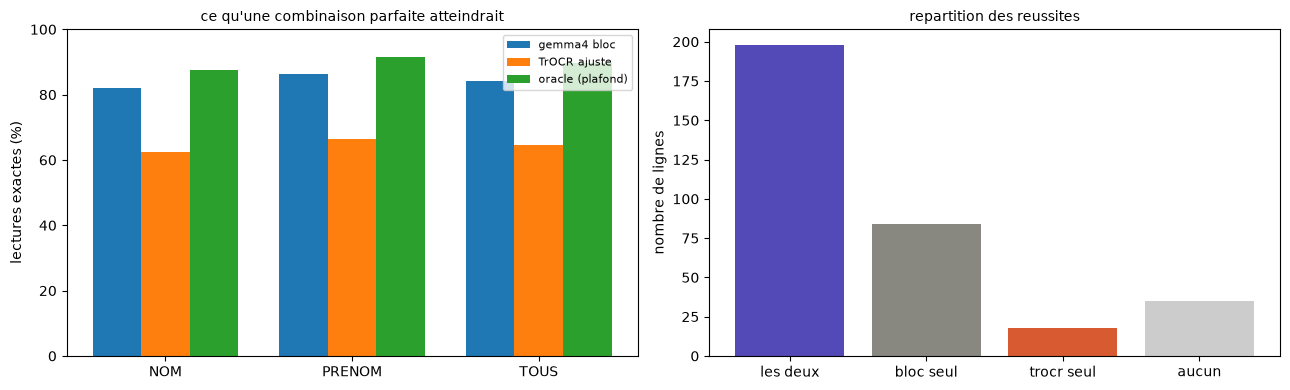

In [23]:
if pred_bloc is not None and len(croisement):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    x = np.arange(len(croisement))
    w = 0.26
    axes[0].bar(x - w, croisement["bloc"] * 100, w, label="gemma4 bloc")
    axes[0].bar(x, croisement["trocr"] * 100, w, label="TrOCR ajuste")
    axes[0].bar(x + w, croisement["oracle"] * 100, w, label="oracle (plafond)")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(croisement.champ)
    axes[0].set_ylabel("lectures exactes (%)")
    axes[0].set_ylim(0, 100)
    axes[0].set_title("ce qu'une combinaison parfaite atteindrait", fontsize=10)
    axes[0].legend(fontsize=8)

    tous_c = croisement[croisement.champ == "TOUS"]
    if len(tous_c):
        c = tous_c.iloc[0]
        axes[1].bar(["les deux", "bloc seul", "trocr seul", "aucun"],
                    [c.les_deux, c.bloc_seul, c.trocr_seul, c.aucun],
                    color=["#534AB7", "#888780", "#D85A30", "#CCC"])
        axes[1].set_ylabel("nombre de lignes")
        axes[1].set_title("repartition des reussites", fontsize=10)

    plt.tight_layout()
    plt.savefig("complementarite.png", dpi=150)
    plt.show()

In [24]:
# L'essai de synthese
with mlflow.start_run(run_name=f"synthese-cv-et-complementarite-{CAMPAGNE}"):
    mlflow.log_params({
        "type": "synthese", "modele_ajuste": MODELE_DEPART,
        "modele_service": MODELE_SERVICE, "k_blocs": K_BLOCS,
        "graine": GRAINE, "campagne": CAMPAGNE,
        "N_bulletins": len({l["cle"] for l in LIGNES}),
        "N_lignes": len(LIGNES),
    })
    mes = {}
    for champ in CHAMPS + ["TOUS"]:
        gp = apres if champ == "TOUS" else apres[apres.champ == champ]
        if len(gp):
            k, n = int(gp.exact.sum()), len(gp)
            lo, hi = wilson(k, n)
            mes[f"trocr_{champ}_exact"] = float(k / n)
            mes[f"trocr_{champ}_ic_largeur"] = float(hi - lo)
    if pred_bloc is not None and len(croisement):
        for _, c in croisement.iterrows():
            mes[f"bloc_{c.champ}_exact"] = float(c["bloc"])
            mes[f"oracle_{c.champ}"] = float(c["oracle"])
            mes[f"marge_{c.champ}"] = float(c["marge"])
            mes[f"co_echec_{c.champ}"] = float(c["co_echec"])
    mlflow.log_metrics(mes)
    for f in ["resume_cv.csv", "cv_trocr.csv", "complementarite.csv",
              "complementarite.png", CHEMIN_BLOC]:
        if Path(f).exists():
            mlflow.log_artifact(f)

print("synthese enregistree\n")
for k, v in sorted(mes.items()):
    print(f"  {k:28} {v:.4f}")

🏃 View run synthese-cv-et-complementarite-RG25 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/dc4c51676ab4405f995bac43d192172c
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1
synthese enregistree

  bloc_NOM_exact               0.8210
  bloc_PRENOM_exact            0.8620
  bloc_TOUS_exact              0.8420
  co_echec_NOM                 1.8700
  co_echec_PRENOM              1.8200
  co_echec_TOUS                1.8600
  marge_NOM                    0.0540
  marge_PRENOM                 0.0540
  marge_TOUS                   0.0540
  oracle_NOM                   0.8750
  oracle_PRENOM                0.9160
  oracle_TOUS                  0.8960
  trocr_NOM_exact              0.6250
  trocr_NOM_ic_largeur         0.1449
  trocr_PRENOM_exact           0.6647
  trocr_PRENOM_ic_largeur      0.1418
  trocr_TOUS_exact             0.6448
  trocr_TOUS_ic_largeur        0.1020
